# Long Short-Term Memory (LSTM) for Time Series Forecasting
This notebook demonstrates how to implement an LSTM network from scratch using TensorFlow for forecasting stock prices based on historical data.

## 1. Importing Required Libraries
We'll start by importing essential Python libraries for data manipulation, visualization, and model building.

In [4]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import logging
%matplotlib inline
plt.style.use('ggplot')
import tensorflow.compat.v1 as tf
import warnings

tf.disable_v2_behavior()
logging.getLogger("tensorflow").setLevel(logging.ERROR)
warnings.filterwarnings('ignore')



## 2. Loading the Dataset
The dataset is downloaded from Kaggle using `kagglehub`. Ensure you have access to the dataset and are authenticated with Kaggle.

In [5]:
import kagglehub
import os
# Download latest version
path = kagglehub.dataset_download("prasoonkottarathil/btcinusd")

print("Path to dataset files:", path)
os.listdir(path)
file_path = os.path.join(path, 'BTC-Daily.csv')



Path to dataset files: /kaggle/input/btcinusd


## 3. Exploring the Data
We preview the loaded dataset to understand its structure.

In [6]:
df = pd.read_csv(file_path)
df.head()

,unix,date,symbol,open,high,low,close,Volume BTC,Volume USD
0,1646092800,2022-03-01 00:00:00,BTC/USD,43221.71,43626.49,43185.48,43185.48,49.006289,2.116360e+06
1,1646006400,2022-02-28 00:00:00,BTC/USD,37717.10,44256.08,37468.99,43178.98,3160.618070,1.364723e+08
2,1645920000,2022-02-27 00:00:00,BTC/USD,39146.66,39886.92,37015.74,37712.68,1701.817043,6.418008e+07
3,1645833600,2022-02-26 00:00:00,BTC/USD,39242.64,40330.99,38600.00,39146.66,912.724087,3.573010e+07
4,1645747200,2022-02-25 00:00:00,BTC/USD,38360.93,39727.97,38027.61,39231.64,2202.851827,8.642149e+07


In [7]:
data = df['close'].values

## 4. Selecting and Normalizing the Target Column
We extract the 'close' price column and normalize it using `StandardScaler` to stabilize learning.

In [8]:
scaler = StandardScaler()
data = scaler.fit_transform(data.reshape(-1, 1))

## 5. Visualizing Normalized Data
This plot helps in understanding how the stock price varies over time.

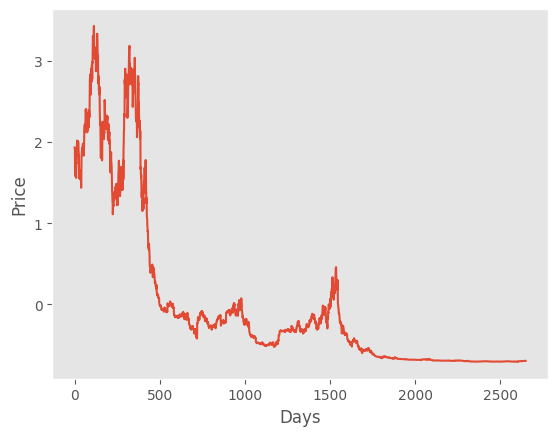

In [9]:
plt.plot(data)
plt.xlabel('Days')
plt.ylabel('Price')
plt.grid()

## 6. Preparing Training and Testing Datasets
Split the sequences into training and testing sets for model evaluation.

In [10]:
def get_data(data, window_size):
  X = []
  y = []
  i = 0
  while (i + window_size) <= len(data) - 1:
    X.append(data[i:i+window_size])
    y.append(data[i+window_size])
    i += 1
  assert len(X) == len(y)
  return X, y

In [11]:
X, y = get_data(data, window_size = 7)

In [12]:
#train set
X_train = np.array(X[:1000])
y_train = np.array(y[:1000])
#test set
X_test = np.array(X[1000:])
y_test = np.array(y[1000:])

In [13]:
X_train.shape

(1000, 7, 1)

## 7. LSTM Hyperparameters
Define key hyperparameters such as batch size, sequence length (window), and hidden layer size.

In [14]:
batch_size = 7
window_size = 7
hidden_layer = 256
learning_rate = 0.001

## 8. Initializing LSTM Weights
Initialize the weight matrices for the input, forget, output, and candidate gates.

In [15]:
input = tf.placeholder(tf.float32, [batch_size, window_size, 1])
target = tf.placeholder(tf.float32, [batch_size, 1])

In [16]:
U_i = tf.Variable(tf.truncated_normal([1, hidden_layer], stddev=0.05))
W_i = tf.Variable(tf.truncated_normal([hidden_layer, hidden_layer], stddev=0.05))
b_i = tf.Variable(tf.zeros([hidden_layer]))

In [17]:
U_f = tf.Variable(tf.truncated_normal([1, hidden_layer], stddev=0.05))
W_f = tf.Variable(tf.truncated_normal([hidden_layer, hidden_layer], stddev=0.05))
b_f = tf.Variable(tf.zeros([hidden_layer]))

In [18]:
U_o = tf.Variable(tf.truncated_normal([1, hidden_layer], stddev=0.05))
W_o = tf.Variable(tf.truncated_normal([hidden_layer, hidden_layer], stddev=0.05))
b_o = tf.Variable(tf.zeros([hidden_layer]))

In [19]:
U_g = tf.Variable(tf.truncated_normal([1, hidden_layer], stddev=0.05))
W_g = tf.Variable(tf.truncated_normal([hidden_layer, hidden_layer], stddev=0.05))
b_g = tf.Variable(tf.zeros([hidden_layer]))

In [20]:
V = tf.Variable(tf.truncated_normal([hidden_layer, 1], stddev=0.05))
b_v = tf.Variable(tf.zeros([1]))

## 9. Defining the LSTM Cell
This function computes the forward pass of a single LSTM cell using basic matrix operations.

In [21]:
def LSTM_cell(input, prev_hidden_state, prev_cell_state):
    it = tf.sigmoid(tf.matmul(input, U_i) + tf.matmul(prev_hidden_state, W_i) + b_i)
    ft = tf.sigmoid(tf.matmul(input, U_f) + tf.matmul(prev_hidden_state, W_f) + b_f)
    ot = tf.sigmoid(tf.matmul(input, U_o) + tf.matmul(prev_hidden_state, W_o) + b_o)
    gt = tf.tanh(tf.matmul(input, U_g) + tf.matmul(prev_hidden_state, W_g) + b_g)
    ct = (prev_cell_state * ft) + (it * gt)
    ht = ot * tf.tanh(ct)
    return ct, ht


## 10. Forward Propagation
We process each batch through the LSTM cell to obtain predictions.

In [22]:
y_hat = []
for i in range(batch_size):
    hidden_state = np.zeros([1, hidden_layer], dtype=np.float32)
    cell_state = np.zeros([1, hidden_layer], dtype=np.float32)
    for t in range(window_size):
        cell_state, hidden_state = LSTM_cell(tf.reshape(input[i][t], (-1, 1)), hidden_state, cell_state)
    y_hat.append(tf.matmul(hidden_state, V) + b_v)

## 11. Loss Calculation
Compute mean squared error loss for each batch.

In [23]:
losses = []

for i in range(len(y_hat)):
    losses.append(tf.losses.mean_squared_error(tf.reshape(target[i], (-1, 1)), y_hat[i]))
loss = tf.reduce_mean(losses)

gradients = tf.gradients(loss, tf.trainable_variables())
clipped, _ = tf.clip_by_global_norm(gradients, 4.0)

optimizer = tf.train.AdamOptimizer(learning_rate).apply_gradients(zip(gradients, tf.trainable_variables()))

## 12. Training the Model
Run the training loop using TensorFlow's session execution environment.

In [24]:
# train LSTM

session = tf.Session()
session.run(tf.global_variables_initializer())

epochs = 100

for i in range(epochs):
    train_predictions = []
    index = 0
    epoch_loss = []
    while(index + batch_size) <= len(X_train):
        X_batch = X_train[index:index+batch_size]
        y_batch = y_train[index:index+batch_size]
        predicted, loss_val, _ = session.run([y_hat, loss, optimizer], feed_dict={input:X_batch, target:y_batch})
        epoch_loss.append(loss_val)
        train_predictions.append(predicted)
        index += batch_size
    if (i % 10)== 0:
        print(f"Epoch {i}, Loss: {np.mean(epoch_loss)}")

Epoch 0, Loss: 0.212823286652565
Epoch 10, Loss: 0.07849486172199249
Epoch 20, Loss: 0.03830669820308685
Epoch 30, Loss: 0.0231208223849535
Epoch 40, Loss: 0.01670379750430584
Epoch 50, Loss: 0.014843353070318699
Epoch 60, Loss: 0.01417754776775837
Epoch 70, Loss: 0.012274077162146568
Epoch 80, Loss: 0.015241376124322414
Epoch 90, Loss: 0.010486905463039875


## 13. Making Predictions
Once the model is trained, we use it to generate predictions on the test data.

In [25]:
# make predictions using LSTM
predicted_output = []
i = 0

while i+batch_size <= len(X_test):
    output = session.run([y_hat],feed_dict={input:X_test[i:i+batch_size]})
    i += batch_size
    predicted_output.append(output)

predicted_output[0]

[[array([[-0.19839244]], dtype=float32),
  array([[-0.17888795]], dtype=float32),
  array([[-0.17254673]], dtype=float32),
  array([[-0.17309617]], dtype=float32),
  array([[-0.17298011]], dtype=float32),
  array([[-0.21372811]], dtype=float32),
  array([[-0.22191475]], dtype=float32)]]

## 14. Post-processing Predictions
Flatten the predictions to match the actual data's format.

In [26]:
predicted_values_test = []
for i in range(len(predicted_output)):
    for j in range(len(predicted_output[i][0])):
        predicted_values_test.append(predicted_output[i][0][j])

predicted_values_test[0]

array([[-0.19839244]], dtype=float32)

In [27]:
predicted_values_test = [x for x in predicted_values_test]


## 15. Visualizing Results
Plot the actual vs predicted values to evaluate model performance visually.

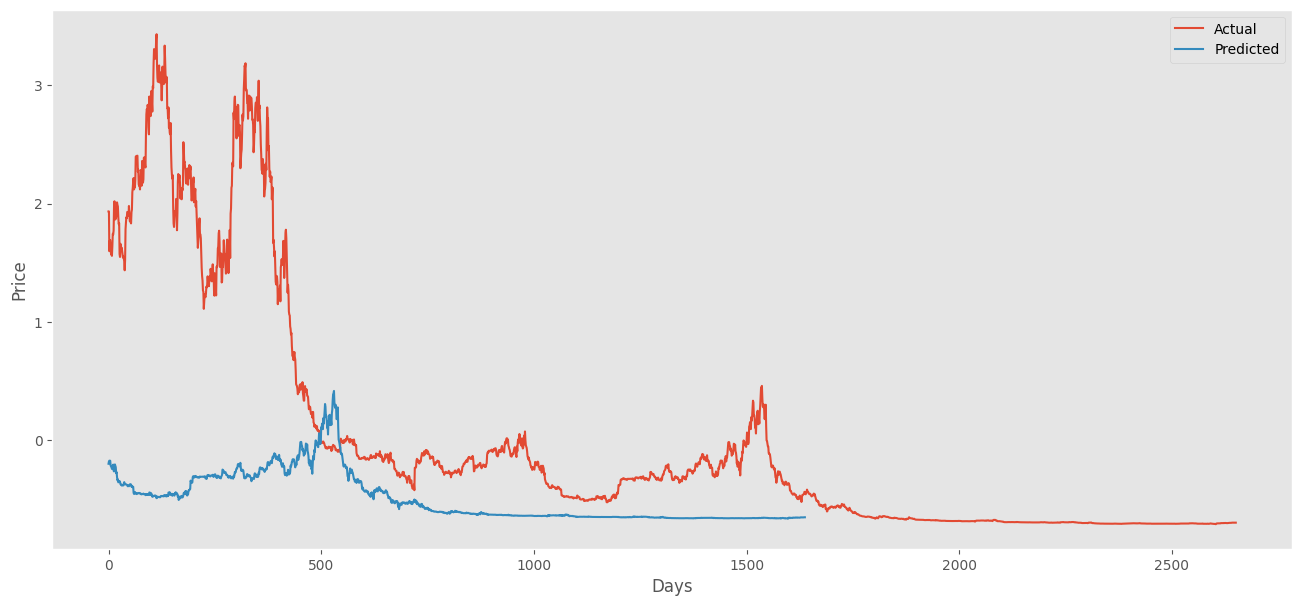

In [29]:
plt.figure(figsize=(16, 7))
plt.plot(data, label='Actual')
plt.plot(np.array(predicted_values_test).reshape(-1), label='Predicted')
plt.legend()
plt.xlabel('Days')
plt.ylabel('Price')
plt.grid()
plt.show()
